# Visualize payment time, space, and lifecycle behavior

**Goal.** Explore a bounded, deterministic payment world through computed tables and plots.

**Audience.** Data scientists and ML engineers learning FraudTwin's core simulation workflows.

**Prerequisites.** Python 3.12+, FraudTwin, and Polars. Optional plotting cells can install notebook packages.

**Source size.** 1,000 logical payments; outputs are reproducible and temporary.

**Offline path.** Analysis runs without Kafka, databases, or cloud services.


## Optional notebook packages
Run this only for richer plots or t-SNE output.

```bash
!pip install matplotlib scikit-learn
```


## 1. Generate the source world


In [1]:
from pathlib import Path

import polars as pl

import fraudtwin
from fraudtwin.config import SimulationRunConfig, load_config

root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "configs" / "minimal-v1.yaml").is_file()
)
base = load_config(root / "configs" / "minimal-v1.yaml")
values = base.model_dump(mode="python")
values["payments"]["daily_target"] = 100
values["simulation"]["duration_days"] = 10
values["population"].update(
    {
        "customers": 100,
        "accounts": 200,
        "cards": 200,
        "merchants": 30,
        "devices": 200,
        "pix_keys": 100,
    }
)
values["behavior"]["amount_max"] = 100
values["simulation"]["seed"] = 2501
config = SimulationRunConfig.model_validate(values)
data = fraudtwin.generate(config)
print({"run_id": data.run_id, "payments": len(data.behavior.payments)})
assert len(data.behavior.payments) >= 1_000

{'run_id': 'RUN-f61020a6db72d42d', 'payments': 1000}


## 2. Analysis step


In [2]:
payments = pl.DataFrame(
    [
        {
            "payment_id": p.payment_id,
            "rail": p.payment_rail,
            "amount": p.amount,
            "status": p.current_status,
        }
        for p in data.behavior.payments
    ]
)
display(payments.head())
assert payments.height == 1_000

payment_id,rail,amount,status
str,str,f64,str
"""PAY-00000001""","""ACCOUNT_TRANSFER""",99.14,"""COMPLETED"""
"""PAY-00000002""","""CARD""",60.55,"""SETTLED"""
"""PAY-00000003""","""ACCOUNT_TRANSFER""",51.47,"""COMPLETED"""
"""PAY-00000004""","""ACCOUNT_TRANSFER""",1.92,"""COMPLETED"""
"""PAY-00000005""","""PIX""",10.19,"""RECEIVED"""


## 3. Analysis step


In [3]:
rail_counts = payments.group_by("rail").len().sort("len", descending=True)
rail_counts

rail,len
str,u32
"""CARD""",587
"""PIX""",228
"""ACCOUNT_TRANSFER""",185


## 4. Analysis step


In [4]:
amount_summary = payments.select(
    [
        pl.col("amount").min().alias("min"),
        pl.col("amount").median().alias("median"),
        pl.col("amount").max().alias("max"),
    ]
)
amount_summary

min,median,max
f64,f64,f64
1.24,28.54,100.0


## 5. Analysis step


In [5]:
event_frame = pl.DataFrame(
    [
        {"event_type": e.event_type, "event_time": e.event_time, "payment_id": e.payment_id}
        for e in data.behavior.payment_events
    ]
)
event_frame.group_by("event_type").len().sort("len", descending=True).head(10)

event_type,len
str,u32
"""CARD_PAYMENT_INITIATED""",587
"""CARD_AUTHORIZATION_REQUESTED""",587
"""CARD_AUTHORIZED""",532
"""CARD_CAPTURED""",519
"""CARD_SETTLED""",508
"""CARD_CLEARED""",508
"""PIX_VALIDATED""",228
"""PIX_INITIATED""",228
"""PIX_SETTLED""",219


## 6. Analysis step


In [6]:
hourly = (
    event_frame.with_columns(pl.col("event_time").dt.hour().alias("hour"))
    .group_by("hour")
    .len()
    .sort("hour")
)
display(hourly)

hour,len
i8,u32
0,58
1,63
2,71
3,108
4,81
…,…
19,199
20,275
21,274


## 7. Analysis step


In [7]:
lifecycle = event_frame.group_by(["payment_id", "event_type"]).len()
print({"payments_with_events": lifecycle.select("payment_id").n_unique()})

{'payments_with_events': 1000}


## 8. Analysis step


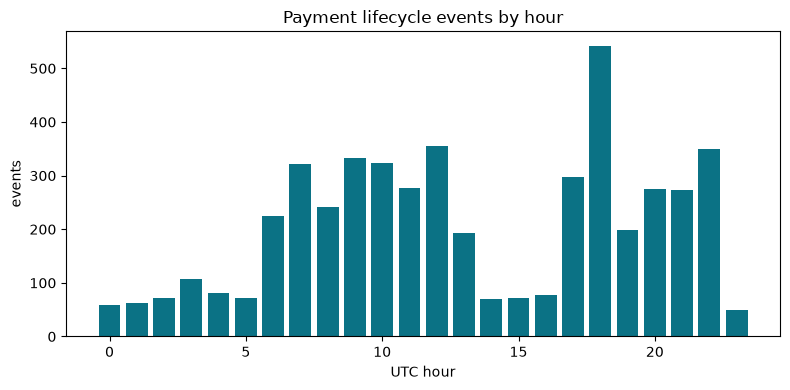

In [8]:
try:
    import matplotlib.pyplot as plt

    fig, axis = plt.subplots(figsize=(8, 4))
    axis.bar(hourly["hour"].to_list(), hourly["len"].to_list(), color="#0b7285")
    axis.set(title="Payment lifecycle events by hour", xlabel="UTC hour", ylabel="events")
    fig.tight_layout()
    plt.show()
    plt.close(fig)
except ImportError:
    print("Install matplotlib to render the lifecycle chart.")

## 9. Analysis step


In [9]:
fingerprint = fraudtwin.aggregate_fingerprint([dict(row) for row in payments.to_dicts()])
print({"payment_fingerprint": f"{fingerprint}"})
assert isinstance(fingerprint, str) and fingerprint

{'payment_fingerprint': 'cbbbc87581d82883ee5a4a957f7c037eff24f8fe08607e1295db754d788036f2'}


In [ ]:
assert hourly.height > 0
assert fingerprint
print("Lifecycle analysis contract passed")